# Single-Plaquette Stabilizer Readout

This notebook builds the five-atom Rb-Cs stabilizer-readout example with manual Hamiltonian blocks.

The geometry is one Cs ancilla at the center of a square and four Rb data atoms at the vertices. The Rb bitstrings reduce to six symmetry classes:

| Class | Representative | Weight | Target Cs state |
| --- | --- | ---: | --- |
| `m0` | `0000` | 1 | `|+>` |
| `m1` | `1000` | 4 | `|->` |
| `m2_edge` | `1100` | 4 | `|+>` |
| `m2_diag` | `1010` | 2 | `|+>` |
| `m3` | `1110` | 4 | `|->` |
| `m4` | `1111` | 1 | `|+>` |

The block Hamiltonian for each case is

$$
H_k = H_{\rm Rb}(k)\otimes I_{\rm Cs}
+ I_{\rm Rb}\otimes H_{\rm Cs}(k)
+ B_{\rm RbCs}\,N_{\rm Rb}\otimes |r\rangle\langle r|,
\qquad
H_{\rm Rb}\supset \Delta_{\rm Rb}N_{\rm Rb},
\qquad
H_{\rm Cs}\supset \Delta_{\rm Cs}|r\rangle\langle r|.
$$

The Rb part is built in a raw subset basis and then projected into a symmetry-reduced basis. This keeps the implementation explicit while still using smaller block dimensions.

In [1]:
from __future__ import annotations

from dataclasses import dataclass
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

project_root = Path.cwd()
if project_root.name == "stabilizer_readout":
    project_root = project_root.parent.parent
elif project_root.name == "examples":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "src"))

from time_optimal_grape import (
    ControlLayout,
    ControlValues,
    CurvatureRobustnessSettings,
    CurvaturePenalty,
    GrapeOptimizer,
    GrapeProblem,
    ManualHamiltonianBlock,
    MultiParameterRobustGrapeOptimizer,
    OptimizationResult,
    OptimizerSettings,
    TimeContinuationScanner,
    TimeScanSettings,
    WeightedOverlapFidelity,
    assemble_parameters,
    basis_state,
    constant_control_profile,
    locked_parameter_indices,
    normalized_state,
    phase_sample_axis,
    random_control_profile,
    scan_parameter_sensitivity,
    trace_populations,
    unwrap_phase_profile,
    zero_control_profile,
)

## Controls and Interactions

The time-dependent controls are

$$
\phi_{\rm Rb}(k),\qquad \phi_{\rm Cs}(k),\qquad \rho(k)=\Omega_{\rm Cs}(k)/\Omega_{\rm Rb}.
$$

Thus

$$
\Omega_{\rm Cs}(k)=\rho(k)\Omega_{\rm Rb}.
$$

The static diagonal parameters are

$$
B_{\rm RbCs},\qquad B_e,\qquad B_d,\qquad \Delta_{\rm Rb},\qquad \Delta_{\rm Cs},
$$

where \(B_e\) is the Rb-Rb edge interaction, \(B_d\) is the Rb-Rb diagonal interaction, and \(\Delta_{\rm Rb},\Delta_{\rm Cs}\) are differential AC Stark shifts on Rydberg states. In code these are `rb_stark_shift` and `cs_stark_shift`.

In [2]:
@dataclass(frozen=True)
class ReadoutParameters:
    omega_rb: float
    b_rb_cs: float
    b_edge: float
    b_diag: float
    rb_stark_shift: float
    cs_stark_shift: float


VERTICES = (0, 1, 2, 3)
EDGE_PAIRS = frozenset({frozenset((0, 1)), frozenset((1, 2)), frozenset((2, 3)), frozenset((3, 0))})
DIAG_PAIRS = frozenset({frozenset((0, 2)), frozenset((1, 3))})
CS_STATES = {"1": 0, "r": 1}


@dataclass(frozen=True)
class ReducedVector:
    label: str
    amplitudes: dict[frozenset[int], complex]


@dataclass(frozen=True)
class ClassSpec:
    name: str
    representative: str
    active_vertices: tuple[int, ...]
    weight: int
    target_cs_state: str
    reduced_vectors: tuple[ReducedVector, ...]


## Reduced Rb Bases

Each reduced vector is a superposition of raw Rb Rydberg subsets. For example,

$$
|W_1\rangle=\frac{1}{2}\sum_{j=1}^4 |r_j\rangle.
$$

The code below defines one reduced Rb basis for each of the six classes.

In [3]:
def rv(label: str, terms: tuple[tuple[tuple[int, ...], complex], ...]) -> ReducedVector:
    return ReducedVector(
        label=label,
        amplitudes={frozenset(vertices): amplitude for vertices, amplitude in terms},
    )


CLASS_SPECS = (
    ClassSpec(
        name="m0",
        representative="0000",
        active_vertices=(),
        weight=1,
        target_cs_state="+",
        reduced_vectors=(rv("G", (((), 1.0),)),),
    ),
    ClassSpec(
        name="m1",
        representative="1000",
        active_vertices=(0,),
        weight=4,
        target_cs_state="-",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("R", (((0,), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m2_edge",
        representative="1100",
        active_vertices=(0, 1),
        weight=4,
        target_cs_state="+",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("W", (((0,), 1 / np.sqrt(2)), ((1,), 1 / np.sqrt(2)))),
            rv("D_e", (((0, 1), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m2_diag",
        representative="1010",
        active_vertices=(0, 2),
        weight=2,
        target_cs_state="+",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("W", (((0,), 1 / np.sqrt(2)), ((2,), 1 / np.sqrt(2)))),
            rv("D_d", (((0, 2), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m3",
        representative="1110",
        active_vertices=(0, 1, 3),
        weight=4,
        target_cs_state="-",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("S_a", (((0,), 1.0),)),
            rv("S_b", (((1,), 1 / np.sqrt(2)), ((3,), 1 / np.sqrt(2)))),
            rv("D_e", (((0, 1), 1 / np.sqrt(2)), ((0, 3), 1 / np.sqrt(2)))),
            rv("D_d", (((1, 3), 1.0),)),
            rv("T", (((0, 1, 3), 1.0),)),
        ),
    ),
    ClassSpec(
        name="m4",
        representative="1111",
        active_vertices=(0, 1, 2, 3),
        weight=1,
        target_cs_state="+",
        reduced_vectors=(
            rv("G", (((), 1.0),)),
            rv("W_1", tuple(((vertex,), 0.5) for vertex in VERTICES)),
            rv("D_e", tuple((tuple(pair), 0.5) for pair in EDGE_PAIRS)),
            rv("D_d", tuple((tuple(pair), 1 / np.sqrt(2)) for pair in DIAG_PAIRS)),
            rv("W_3", tuple((tuple(v for v in VERTICES if v != missing), 0.5) for missing in VERTICES)),
            rv("Q", (((0, 1, 2, 3), 1.0),)),
        ),
    ),
)


## Matrix Construction

For a raw Rb Rydberg subset \(A\), the diagonal Rb contribution is

$$
E_{\rm Rb}(A)=\Delta_{\rm Rb}|A|+B_eN_e(A)+B_dN_d(A).
$$

The Cs Stark shift is included as \(\Delta_{\rm Cs}|r\rangle\langle r|\), and the Cs-Rb interaction is added after projection as

$$
B_{\rm RbCs}N_{\rm Rb}\otimes |r\rangle\langle r|.
$$

The Rb drive toggles one active Rb atom in or out of the Rydberg subset, and the Cs drive couples \(|1\rangle_{\rm Cs}\leftrightarrow |r\rangle_{\rm Cs}\).

In [4]:
def all_subsets(vertices: tuple[int, ...]) -> tuple[frozenset[int], ...]:
    subsets: list[frozenset[int]] = []
    for mask in range(2 ** len(vertices)):
        subset = frozenset(vertex for bit, vertex in enumerate(vertices) if mask & (1 << bit))
        subsets.append(subset)
    return tuple(subsets)


def count_pairs(subset: frozenset[int], pairs: frozenset[frozenset[int]]) -> int:
    return sum(1 for pair in pairs if pair.issubset(subset))


def rb_interaction_energy(subset: frozenset[int], parameters: ReadoutParameters) -> float:
    rydberg_count = len(subset)
    return (
        parameters.rb_stark_shift * rydberg_count
        + parameters.b_edge * count_pairs(subset, EDGE_PAIRS)
        + parameters.b_diag * count_pairs(subset, DIAG_PAIRS)
    )


def reduced_projection(spec: ClassSpec) -> np.ndarray:
    raw_subsets = all_subsets(spec.active_vertices)
    raw_index = {subset: index for index, subset in enumerate(raw_subsets)}
    projection = np.zeros((len(raw_subsets), len(spec.reduced_vectors)), dtype=np.complex128)
    for column_index, vector in enumerate(spec.reduced_vectors):
        for subset, amplitude in vector.amplitudes.items():
            projection[raw_index[subset], column_index] = amplitude
    gram = projection.conj().T @ projection
    if not np.allclose(gram, np.eye(gram.shape[0]), atol=1e-12):
        raise ValueError(f"Reduced basis for {spec.name} is not orthonormal.")
    return projection


def raw_rb_matrices(
    spec: ClassSpec,
    control_values: ControlValues,
    sample_index: int,
    parameters: ReadoutParameters,
) -> tuple[np.ndarray, np.ndarray]:
    raw_subsets = all_subsets(spec.active_vertices)
    raw_index = {subset: index for index, subset in enumerate(raw_subsets)}
    dimension = len(raw_subsets)
    hamiltonian = np.zeros((dimension, dimension), dtype=np.complex128)
    derivative_phi_rb = np.zeros_like(hamiltonian)
    phi_rb = control_values.time_controls["phi_rb"][sample_index]
    drive = parameters.omega_rb * np.exp(1j * phi_rb) / 2.0
    drive_derivative = 1j * drive

    for subset in raw_subsets:
        subset_index = raw_index[subset]
        hamiltonian[subset_index, subset_index] = rb_interaction_energy(subset, parameters)
        for vertex in spec.active_vertices:
            if vertex not in subset:
                coupled_subset = frozenset(set(subset) | {vertex})
                coupled_index = raw_index[coupled_subset]
                hamiltonian[subset_index, coupled_index] = drive
                hamiltonian[coupled_index, subset_index] = np.conj(drive)
                derivative_phi_rb[subset_index, coupled_index] = drive_derivative
                derivative_phi_rb[coupled_index, subset_index] = np.conj(drive_derivative)

    return hamiltonian, derivative_phi_rb


def reduced_rb_matrices(
    spec: ClassSpec,
    control_values: ControlValues,
    sample_index: int,
    parameters: ReadoutParameters,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    projection = reduced_projection(spec)
    raw_hamiltonian, raw_derivative_phi_rb = raw_rb_matrices(spec, control_values, sample_index, parameters)
    raw_subsets = all_subsets(spec.active_vertices)
    raw_number_operator = np.diag([len(subset) for subset in raw_subsets]).astype(np.complex128)
    return (
        projection.conj().T @ raw_hamiltonian @ projection,
        projection.conj().T @ raw_derivative_phi_rb @ projection,
        projection.conj().T @ raw_number_operator @ projection,
    )


In [5]:
def cs_hamiltonian(control_values: ControlValues, sample_index: int, parameters: ReadoutParameters) -> np.ndarray:
    phi_cs = control_values.time_controls["phi_cs"][sample_index]
    ratio_cs = control_values.time_controls["ratio_cs"][sample_index]
    drive = ratio_cs * parameters.omega_rb * np.exp(1j * phi_cs) / 2.0
    matrix = np.zeros((2, 2), dtype=np.complex128)
    matrix[CS_STATES["r"], CS_STATES["r"]] = parameters.cs_stark_shift
    matrix[CS_STATES["1"], CS_STATES["r"]] = drive
    matrix[CS_STATES["r"], CS_STATES["1"]] = np.conj(drive)
    return matrix


def d_cs_d_phi_cs(control_values: ControlValues, sample_index: int, parameters: ReadoutParameters) -> np.ndarray:
    phi_cs = control_values.time_controls["phi_cs"][sample_index]
    ratio_cs = control_values.time_controls["ratio_cs"][sample_index]
    drive_derivative = 1j * ratio_cs * parameters.omega_rb * np.exp(1j * phi_cs) / 2.0
    matrix = np.zeros((2, 2), dtype=np.complex128)
    matrix[CS_STATES["1"], CS_STATES["r"]] = drive_derivative
    matrix[CS_STATES["r"], CS_STATES["1"]] = np.conj(drive_derivative)
    return matrix


def d_cs_d_ratio_cs(control_values: ControlValues, sample_index: int, parameters: ReadoutParameters) -> np.ndarray:
    phi_cs = control_values.time_controls["phi_cs"][sample_index]
    drive_derivative = parameters.omega_rb * np.exp(1j * phi_cs) / 2.0
    matrix = np.zeros((2, 2), dtype=np.complex128)
    matrix[CS_STATES["1"], CS_STATES["r"]] = drive_derivative
    matrix[CS_STATES["r"], CS_STATES["1"]] = np.conj(drive_derivative)
    return matrix


def full_basis_state(rb_dimension: int, rb_index: int, cs_label: str) -> np.ndarray:
    state = np.zeros(2 * rb_dimension, dtype=np.complex128)
    state[2 * rb_index + CS_STATES[cs_label]] = 1.0
    return state


def tensor_state(rb_vector: np.ndarray, cs_vector: np.ndarray) -> np.ndarray:
    return np.kron(rb_vector, cs_vector).astype(np.complex128)


## Build Manual Blocks

Each symmetry class becomes one `ManualHamiltonianBlock`. The fidelity objective uses the six integer weights from the symmetry classes:

$$
F = \frac{\left| \sum_q w_q e^{-i\xi_q}\langle \psi_q^{\rm target}|U_q|\psi_q^0\rangle \right|^2}{16^2}.
$$

Here the parity sign is already part of the target Cs state. The local phase parameters are kept as scalar block phase corrections.

For the diagnostic case with `duration = 2 * np.pi`, `ratio_cs = 0`, and no Rb-Rb interaction, the Rb drive contributes an approximately parity-dependent `(-1)^m` phase. Starting exactly from `theta_rb = 0` makes the coherent weighted sum cancel between even and odd classes, even though each individual block has large overlap. Initializing `theta_rb` near `np.pi` aligns this local Rb phase and avoids a zero-fidelity stationary point.

In [6]:
def make_block(spec: ClassSpec, parameters: ReadoutParameters) -> ManualHamiltonianBlock:
    rb_dimension = len(spec.reduced_vectors)
    cs_plus = normalized_state((1.0, 1.0))
    cs_minus = normalized_state((1.0, -1.0))
    initial_state = tensor_state(basis_state(rb_dimension, 0), cs_plus)
    target_cs = cs_plus if spec.target_cs_state == "+" else cs_minus
    target_state = tensor_state(basis_state(rb_dimension, 0), target_cs)

    def hamiltonian(control_values: ControlValues, sample_index: int) -> np.ndarray:
        rb_hamiltonian, _d_rb, rb_number = reduced_rb_matrices(spec, control_values, sample_index, parameters)
        cs_h = cs_hamiltonian(control_values, sample_index, parameters)
        rb_cs = parameters.b_rb_cs * np.kron(rb_number, np.diag([0.0, 1.0]))
        return np.kron(rb_hamiltonian, np.eye(2)) + np.kron(np.eye(rb_dimension), cs_h) + rb_cs

    def d_hamiltonian_d_phi_rb(control_values: ControlValues, sample_index: int) -> np.ndarray:
        _rb_h, d_rb, _rb_number = reduced_rb_matrices(spec, control_values, sample_index, parameters)
        return np.kron(d_rb, np.eye(2))

    def d_hamiltonian_d_phi_cs(control_values: ControlValues, sample_index: int) -> np.ndarray:
        return np.kron(np.eye(rb_dimension), d_cs_d_phi_cs(control_values, sample_index, parameters))

    def d_hamiltonian_d_ratio_cs(control_values: ControlValues, sample_index: int) -> np.ndarray:
        return np.kron(np.eye(rb_dimension), d_cs_d_ratio_cs(control_values, sample_index, parameters))

    return ManualHamiltonianBlock(
        name=spec.name,
        weight=spec.weight,
        initial_state=initial_state,
        target_state=target_state,
        hamiltonian=hamiltonian,
        derivatives={
            "phi_rb": d_hamiltonian_d_phi_rb,
            "phi_cs": d_hamiltonian_d_phi_cs,
            "ratio_cs": d_hamiltonian_d_ratio_cs,
        },
        phase_offset=0.0,
        local_phase_coefficients={
            "theta_rb": float(spec.active_vertices.__len__()),
            "theta_cs": 1.0,
        },
    )


def make_blocks(parameters: ReadoutParameters) -> tuple[ManualHamiltonianBlock, ...]:
    return tuple(make_block(spec, parameters) for spec in CLASS_SPECS)


for spec in CLASS_SPECS:
    print(spec.name, spec.representative, "weight", spec.weight, "reduced dimension", 2 * len(spec.reduced_vectors))


m0 0000 weight 1 reduced dimension 2
m1 1000 weight 4 reduced dimension 4
m2_edge 1100 weight 4 reduced dimension 6
m2_diag 1010 weight 2 reduced dimension 6
m3 1110 weight 4 reduced dimension 12
m4 1111 weight 1 reduced dimension 12


## Evaluate a Pulse and Optimize Once

In [7]:
samples = 60
duration = 2 * np.pi
parameters = ReadoutParameters(
    omega_rb=1.0,
    b_rb_cs=10.0,
    b_edge=0.1,
    b_diag=0.0,
    rb_stark_shift=0.0,
    cs_stark_shift=0.0,
)

layout = ControlLayout(
    time_control_names=("phi_rb", "phi_cs", "ratio_cs"),
    local_phase_names=("theta_rb", "theta_cs"),
    samples=samples,
)
settings = OptimizerSettings(method="BFGS", max_iterations=300, gradient_tolerance=1e-8, display=False)
problem = GrapeProblem(
    blocks=make_blocks(parameters),
    control_layout=layout,
    duration=duration,
    objective=WeightedOverlapFidelity(normalizer=16.0**2),
    optimizer_settings=settings,
)

rng = np.random.default_rng(123)
initial_parameters = assemble_parameters(
    layout=layout,
    time_controls={
        "phi_rb": constant_control_profile(samples=samples, value=0.0),
        "phi_cs": constant_control_profile(samples=samples, value=0.0),
        "ratio_cs": constant_control_profile(samples=samples, value=0.0),
    },
    local_phases={"theta_rb": np.pi, "theta_cs": 0.0},
)

initial_infidelity, _initial_gradient = GrapeOptimizer(problem).evaluate(initial_parameters)
print(f"initial infidelity: {initial_infidelity:.6e}")

initial infidelity: 1.164714e-01


## Optional Locked-Control Diagnostic

To test the restricted case `Omega_Cs = 0`, set `ratio_cs` to zero in the initial vector and lock all `ratio_cs` samples during optimization.

In [8]:
locked_rng = np.random.default_rng(123)
locked_initial_parameters = assemble_parameters(
    layout=layout,
    time_controls={
        "phi_rb": constant_control_profile(samples=samples, value=0.0),
        "phi_cs": constant_control_profile(samples=samples, value=0.0),
        "ratio_cs": constant_control_profile(samples=samples, value=0.0),
    },
    local_phases={"theta_rb": np.pi, "theta_cs": 0.0},
)
locked_indices = locked_parameter_indices(
    layout=layout,
    time_control_names=("phi_cs", "ratio_cs",),
    local_phase_names=(),
)

locked_initial_infidelity, _locked_initial_gradient = GrapeOptimizer(problem).evaluate(locked_initial_parameters)
locked_result = GrapeOptimizer(problem).optimize_with_locked_parameters(
    initial_parameters=locked_initial_parameters,
    locked_parameter_indices=locked_indices,
)

locked_controls = layout.unpack(locked_result.parameters)
print(f"locked initial infidelity: {locked_initial_infidelity:.6e}")
print(f"locked optimized infidelity: {locked_result.infidelity:.6e}")
print(f"max |ratio_cs| after locked optimization: {np.max(np.abs(locked_controls.time_controls['ratio_cs'])):.3e}")

locked initial infidelity: 1.164714e-01
locked optimized infidelity: 1.253879e-02
max |ratio_cs| after locked optimization: 0.000e+00


In [25]:
# result = GrapeOptimizer(problem).optimize(initial_parameters)
# print(f"success: {result.success}")
# print(f"message: {result.message}")
# print(f"nominal infidelity: {1.0 - result.fidelity:.6e}")

## Plot Optimized Controls

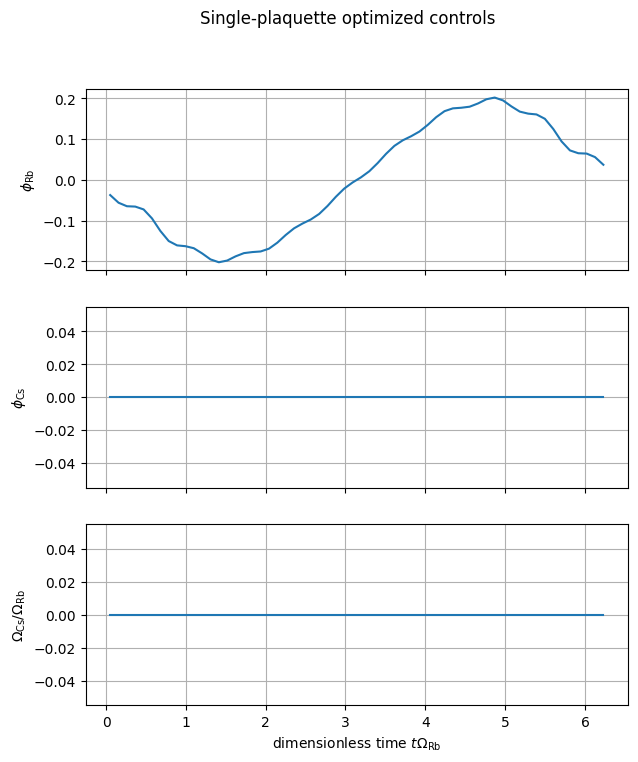

In [9]:
result = locked_result
optimized_controls = layout.unpack(result.parameters)
time_axis = phase_sample_axis(duration=duration, samples=samples)

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
axes[0].plot(time_axis, unwrap_phase_profile(optimized_controls.time_controls["phi_rb"]))
axes[0].set_ylabel(r"$\phi_{\rm Rb}$")
axes[0].grid(True)

axes[1].plot(time_axis, unwrap_phase_profile(optimized_controls.time_controls["phi_cs"]))
axes[1].set_ylabel(r"$\phi_{\rm Cs}$")
axes[1].grid(True)

axes[2].plot(time_axis, optimized_controls.time_controls["ratio_cs"])
axes[2].set_xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
axes[2].set_ylabel(r"$\Omega_{\rm Cs}/\Omega_{\rm Rb}$")
axes[2].grid(True)

fig.suptitle("Single-plaquette optimized controls")
plt.show()

## Reoptimize the Pulse Across Rb Rabi Frequencies

This scan keeps all interaction strengths fixed while changing $\Omega_{\rm Rb}$. For every candidate, the duration is set by $T(\Omega)\Omega=T_0\Omega_0$, and a separate GRAPE optimization is performed. The lower and upper branches are warm-started independently from the nominal optimized pulse, avoiding a single directional continuation bias.

The best point defines the new reference Rabi frequency and phase profile used by the robustness scans below.

Omega_Rb=0.950000, duration=6.613879, fidelity=0.9860945219, success=True
Omega_Rb=0.900000, duration=6.981317, fidelity=0.9845995505, success=True
Omega_Rb=0.850000, duration=7.391983, fidelity=0.9828055651, success=True
Omega_Rb=0.800000, duration=7.853982, fidelity=0.9806492177, success=True
Omega_Rb=1.050000, duration=5.983986, fidelity=0.9885598648, success=True
Omega_Rb=1.100000, duration=5.711987, fidelity=0.9895938986, success=True
Omega_Rb=1.150000, duration=5.463639, fidelity=0.9904500833, success=True
Omega_Rb=1.200000, duration=5.235988, fidelity=0.9912953092, success=True
best Omega_Rb: 1.2000000000
best duration: 5.2359877560
best T*Omega_Rb: 6.2831853072
best optimized fidelity: 0.9912953092


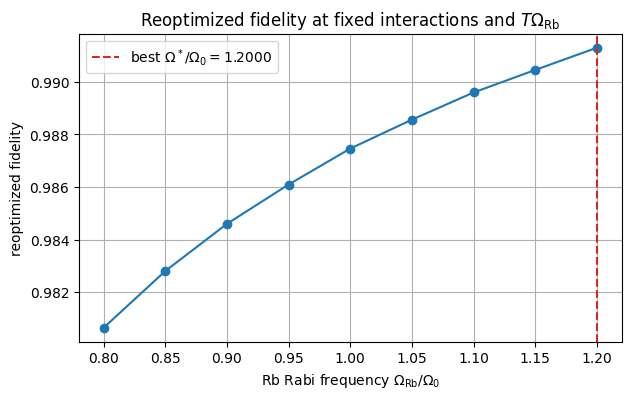

In [10]:
omega0 = parameters.omega_rb
target_pulse_area = duration * omega0


def duration_for_omega(omega_value: float) -> float:
    if omega_value <= 0.0:
        raise ValueError(f"omega_value must be positive: omega_value={omega_value}")
    return target_pulse_area / omega_value


def make_problem_for_omega(omega_value: float) -> GrapeProblem:
    return GrapeProblem(
        blocks=make_blocks(
            ReadoutParameters(
                omega_rb=omega_value,
                b_rb_cs=parameters.b_rb_cs,
                b_edge=parameters.b_edge,
                b_diag=parameters.b_diag,
                rb_stark_shift=parameters.rb_stark_shift,
                cs_stark_shift=parameters.cs_stark_shift,
            )
        ),
        control_layout=layout,
        duration=duration_for_omega(omega_value=omega_value),
        objective=WeightedOverlapFidelity(normalizer=16.0**2),
        optimizer_settings=settings,
    )


def optimize_omega_branch(
    omega_branch_values: np.ndarray,
    initial_parameters: np.ndarray,
) -> tuple[tuple[float, OptimizationResult], ...]:
    current_parameters = np.asarray(initial_parameters, dtype=np.float64)
    branch_points: list[tuple[float, OptimizationResult]] = []

    for omega_value in omega_branch_values:
        omega_problem = make_problem_for_omega(omega_value=float(omega_value))
        omega_result = GrapeOptimizer(omega_problem).optimize_with_locked_parameters(
            initial_parameters=current_parameters,
            locked_parameter_indices=locked_indices,
        )
        branch_points.append((float(omega_value), omega_result))
        current_parameters = omega_result.parameters
        print(
            f"Omega_Rb={omega_value:.6f}, "
            f"duration={omega_problem.duration:.6f}, "
            f"fidelity={omega_result.fidelity:.10f}, "
            f"success={omega_result.success}"
        )

    return tuple(branch_points)


omega_reoptimization_values = np.linspace(
    0.8 * parameters.omega_rb,
    1.2 * parameters.omega_rb,
    9,
    dtype=np.float64,
)
nominal_omega_index = int(np.argmin(np.abs(omega_reoptimization_values - parameters.omega_rb)))
if not np.isclose(omega_reoptimization_values[nominal_omega_index], parameters.omega_rb):
    raise ValueError("omega_reoptimization_values must contain the nominal omega_rb.")

lower_omega_points = optimize_omega_branch(
    omega_branch_values=omega_reoptimization_values[:nominal_omega_index][::-1],
    initial_parameters=result.parameters,
)
upper_omega_points = optimize_omega_branch(
    omega_branch_values=omega_reoptimization_values[nominal_omega_index + 1 :],
    initial_parameters=result.parameters,
)
omega_optimization_points = tuple(
    sorted(
        lower_omega_points
        + ((float(parameters.omega_rb), result),)
        + upper_omega_points,
        key=lambda point: point[0],
    )
)

optimized_omega_values = np.array([point[0] for point in omega_optimization_points], dtype=np.float64)
optimized_omega_fidelities = np.array([point[1].fidelity for point in omega_optimization_points], dtype=np.float64)
best_omega_rb, best_omega_result = max(
    omega_optimization_points,
    key=lambda point: point[1].fidelity,
)
best_omega_problem = make_problem_for_omega(omega_value=best_omega_rb)
best_omega_duration = best_omega_problem.duration
best_omega_controls = layout.unpack(best_omega_result.parameters)

if np.isclose(best_omega_rb, optimized_omega_values[0]) or np.isclose(
    best_omega_rb, optimized_omega_values[-1]
):
    print(
        "WARNING: the best Rabi frequency is on the scan boundary; "
        "expand omega_reoptimization_values before interpreting it as the optimum."
    )

print(f"best Omega_Rb: {best_omega_rb:.10f}")
print(f"best duration: {best_omega_duration:.10f}")
print(f"best T*Omega_Rb: {best_omega_duration * best_omega_rb:.10f}")
print(f"best optimized fidelity: {best_omega_result.fidelity:.10f}")

plt.figure(figsize=(7, 4))
plt.plot(optimized_omega_values / omega0, optimized_omega_fidelities, marker="o")
plt.axvline(
    best_omega_rb / omega0,
    color="tab:red",
    linestyle="--",
    label=rf"best $\Omega^*/\Omega_0={best_omega_rb / omega0:.4f}$",
)
plt.xlabel(r"Rb Rabi frequency $\Omega_{\rm Rb}/\Omega_0$")
plt.ylabel("reoptimized fidelity")
plt.title(r"Reoptimized fidelity at fixed interactions and $T\Omega_{\rm Rb}$")
plt.legend()
plt.grid(True)
plt.show()


## Reoptimize at Longer Gate Durations

This scan keeps $\Omega_{\rm Rb}=\Omega_0$ and all interaction strengths fixed. For each

$$
T'\Omega_0=T\Omega_0+\epsilon,
\qquad \epsilon\ll T\Omega_0,
$$

the Rb phase is reoptimized. The plotted error is $\log_{10}(1-F)$, which should decrease when the extra duration gives the optimizer more control freedom.

epsilon=0.100000, T*Omega0=6.383185, fidelity=0.9878647700, success=True
epsilon=0.200000, T*Omega0=6.483185, fidelity=0.9882850080, success=True
epsilon=0.300000, T*Omega0=6.583185, fidelity=0.9887319212, success=True
epsilon=0.400000, T*Omega0=6.683185, fidelity=0.9891677692, success=True
epsilon=0.500000, T*Omega0=6.783185, fidelity=0.9895695321, success=True
epsilon=0.600000, T*Omega0=6.883185, fidelity=0.9899512533, success=True
epsilon=0.700000, T*Omega0=6.983185, fidelity=0.9903413984, success=True
epsilon=0.800000, T*Omega0=7.083185, fidelity=0.9907416485, success=True
epsilon=0.900000, T*Omega0=7.183185, fidelity=0.9911277171, success=True
epsilon=1.000000, T*Omega0=7.283185, fidelity=0.9914825271, success=True


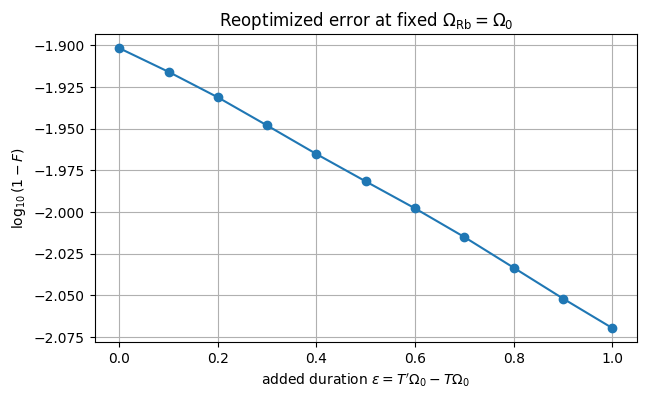

In [11]:
def make_problem_for_epsilon(epsilon_value: float) -> GrapeProblem:
    if epsilon_value < 0.0:
        raise ValueError(f"epsilon_value must be non-negative: epsilon_value={epsilon_value}")
    extended_duration = duration + epsilon_value / omega0
    return GrapeProblem(
        blocks=make_blocks(parameters),
        control_layout=layout,
        duration=extended_duration,
        objective=WeightedOverlapFidelity(normalizer=16.0**2),
        optimizer_settings=settings,
    )


epsilon_reoptimization_values = np.linspace(0.0, 1.0, 11, dtype=np.float64)
duration_optimization_points: list[tuple[float, OptimizationResult]] = [
    (0.0, result)
]
current_duration_parameters = result.parameters

for epsilon_value in epsilon_reoptimization_values[1:]:
    epsilon_problem = make_problem_for_epsilon(epsilon_value=float(epsilon_value))
    epsilon_result = GrapeOptimizer(epsilon_problem).optimize_with_locked_parameters(
        initial_parameters=current_duration_parameters,
        locked_parameter_indices=locked_indices,
    )
    duration_optimization_points.append((float(epsilon_value), epsilon_result))
    current_duration_parameters = epsilon_result.parameters
    print(
        f"epsilon={epsilon_value:.6f}, "
        f"T*Omega0={epsilon_problem.duration * omega0:.6f}, "
        f"fidelity={epsilon_result.fidelity:.10f}, "
        f"success={epsilon_result.success}"
    )

duration_optimization_points_tuple = tuple(duration_optimization_points)
optimized_epsilon_values = np.array(
    [point[0] for point in duration_optimization_points_tuple],
    dtype=np.float64,
)
optimized_duration_infidelities = np.array(
    [point[1].infidelity for point in duration_optimization_points_tuple],
    dtype=np.float64,
)

plt.figure(figsize=(7, 4))
plt.plot(
    optimized_epsilon_values,
    np.log10(np.maximum(optimized_duration_infidelities, 1e-16)),
    marker="o",
)
plt.xlabel(r"added duration $\epsilon=T'\Omega_0-T\Omega_0$")
plt.ylabel(r"$\log_{10}(1-F)$")
plt.title(r"Reoptimized error at fixed $\Omega_{\rm Rb}=\Omega_0$")
plt.grid(True)
plt.show()

## Select the Extended-Duration Profile

Set `selected_epsilon` to the desired extra dimensionless duration. If it is one of the scanned values, the corresponding result is reused. Otherwise, a new optimization is warm-started from the nearest scanned point.

In [12]:
selected_epsilon = 0.5
if selected_epsilon <= 0.0:
    raise ValueError(f"selected_epsilon must be positive: selected_epsilon={selected_epsilon}")

matching_duration_points = tuple(
    point
    for point in duration_optimization_points_tuple
    if np.isclose(point[0], selected_epsilon)
)
selected_duration_problem = make_problem_for_epsilon(epsilon_value=selected_epsilon)

if matching_duration_points:
    selected_duration_result = matching_duration_points[0][1]
else:
    nearest_duration_point = min(
        duration_optimization_points_tuple,
        key=lambda point: abs(point[0] - selected_epsilon),
    )
    selected_duration_result = GrapeOptimizer(
        selected_duration_problem
    ).optimize_with_locked_parameters(
        initial_parameters=nearest_duration_point[1].parameters,
        locked_parameter_indices=locked_indices,
    )

selected_duration = selected_duration_problem.duration
selected_duration_controls = layout.unpack(selected_duration_result.parameters)

print(f"selected epsilon: {selected_epsilon:.10f}")
print(f"selected T*Omega0: {selected_duration * omega0:.10f}")
print(f"selected optimized fidelity: {selected_duration_result.fidelity:.10f}")

selected epsilon: 0.5000000000
selected T*Omega0: 6.7831853072
selected optimized fidelity: 0.9895695321


## Compare the Three Phase Profiles

The original, higher-Rabi-frequency, and extended-duration pulses are plotted on the common $t\Omega_0$ axis. Their different physical durations therefore remain visible.

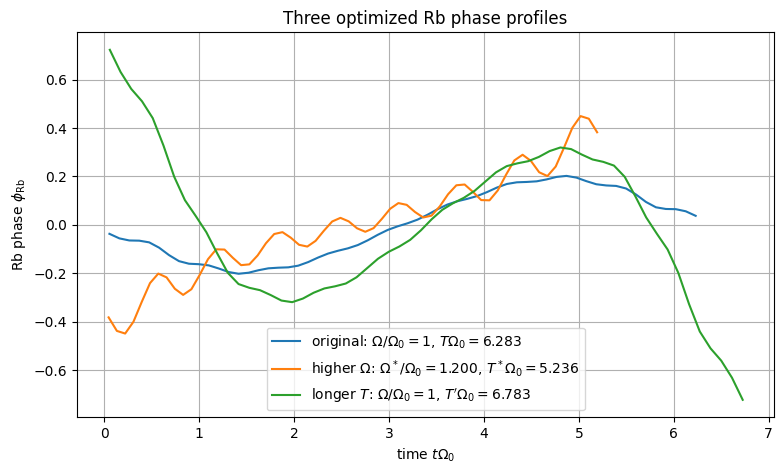

In [13]:
original_phase_time_omega0 = phase_sample_axis(
    duration=duration,
    samples=samples,
) * omega0
high_omega_phase_time_omega0 = phase_sample_axis(
    duration=best_omega_duration,
    samples=samples,
) * omega0
extended_phase_time_omega0 = phase_sample_axis(
    duration=selected_duration,
    samples=samples,
) * omega0

plt.figure(figsize=(9, 5))
plt.plot(
    original_phase_time_omega0,
    unwrap_phase_profile(optimized_controls.time_controls["phi_rb"]),
    # where="mid",
    label=rf"original: $\Omega/\Omega_0=1$, $T\Omega_0={duration * omega0:.3f}$",
)
plt.plot(
    high_omega_phase_time_omega0,
    unwrap_phase_profile(best_omega_controls.time_controls["phi_rb"]),
    # where="mid",
    label=(
        rf"higher $\Omega$: $\Omega^*/\Omega_0={best_omega_rb / omega0:.3f}$, "
        rf"$T^*\Omega_0={best_omega_duration * omega0:.3f}$"
    ),
)
plt.plot(
    extended_phase_time_omega0,
    unwrap_phase_profile(selected_duration_controls.time_controls["phi_rb"]),
    # where="mid",
    label=(
        rf"longer $T$: $\Omega/\Omega_0=1$, "
        rf"$T'\Omega_0={selected_duration * omega0:.3f}$"
    ),
)
plt.xlabel(r"time $t\Omega_0$")
plt.ylabel(r"Rb phase $\phi_{\rm Rb}$")
plt.title("Three optimized Rb phase profiles")
plt.legend()
plt.grid(True)
plt.show()

## Export the Three Phase Profiles

Each JSON file contains one piecewise-constant Rb phase profile together with its reference Rabi frequency and duration.

In [14]:
def save_phase_profile(
    output_path: Path,
    profile_label: str,
    controls: ControlValues,
    reference_omega_rb: float,
    profile_duration: float,
) -> None:
    wrapped_phase = np.angle(
        np.exp(1j * controls.time_controls["phi_rb"])
    ).astype(np.float64)
    payload: dict[str, str | float | int | list[float]] = {
        "profile_label": profile_label,
        "control_name": "phi_rb",
        "interpolation": "piecewise_constant",
        "omega0": float(omega0),
        "reference_omega_rb": float(reference_omega_rb),
        "duration": float(profile_duration),
        "duration_omega0": float(profile_duration * omega0),
        "duration_reference_omega": float(profile_duration * reference_omega_rb),
        "samples": int(wrapped_phase.size),
        "phase_values": wrapped_phase.tolist(),
    }
    output_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    print(f"saved {profile_label} profile: {output_path}")


profile_output_directory = project_root / "examples" / "stabilizer_readout"
save_phase_profile(
    output_path=profile_output_directory / "rb_phase_profile_original.json",
    profile_label="original",
    controls=optimized_controls,
    reference_omega_rb=omega0,
    profile_duration=duration,
)
save_phase_profile(
    output_path=profile_output_directory / "rb_phase_profile_high_omega.json",
    profile_label="high_omega",
    controls=best_omega_controls,
    reference_omega_rb=best_omega_rb,
    profile_duration=best_omega_duration,
)
save_phase_profile(
    output_path=profile_output_directory / "rb_phase_profile_extended_duration.json",
    profile_label="extended_duration",
    controls=selected_duration_controls,
    reference_omega_rb=omega0,
    profile_duration=selected_duration,
)

saved original profile: /Users/lee/Documents/IQOQI/PulseShaping/time_optimal_grape/examples/stabilizer_readout/rb_phase_profile_original.json
saved high_omega profile: /Users/lee/Documents/IQOQI/PulseShaping/time_optimal_grape/examples/stabilizer_readout/rb_phase_profile_high_omega.json
saved extended_duration profile: /Users/lee/Documents/IQOQI/PulseShaping/time_optimal_grape/examples/stabilizer_readout/rb_phase_profile_extended_duration.json


## Three-Profile Intensity Robustness

Each phase profile and its duration are held fixed while the actual Rb Rabi frequency is varied. All three scans share the horizontal coordinate $\Omega/\Omega_0$.

In [15]:
def make_intensity_problem(
    omega_value: float,
    profile_duration: float,
) -> GrapeProblem:
    return GrapeProblem(
        blocks=make_blocks(
            ReadoutParameters(
                omega_rb=omega_value,
                b_rb_cs=parameters.b_rb_cs,
                b_edge=parameters.b_edge,
                b_diag=parameters.b_diag,
                rb_stark_shift=parameters.rb_stark_shift,
                cs_stark_shift=parameters.cs_stark_shift,
            )
        ),
        control_layout=layout,
        duration=profile_duration,
        objective=WeightedOverlapFidelity(normalizer=16.0**2),
        optimizer_settings=settings,
    )


original_intensity_values = np.linspace(0.9 * omega0, 1.1 * omega0, 41, dtype=np.float64)
high_omega_intensity_values = np.linspace(
    0.9 * best_omega_rb,
    1.1 * best_omega_rb,
    41,
    dtype=np.float64,
)
extended_intensity_values = np.linspace(0.9 * omega0, 1.1 * omega0, 41, dtype=np.float64)


def make_original_intensity_problem(omega_value: float) -> GrapeProblem:
    return make_intensity_problem(omega_value=omega_value, profile_duration=duration)


def make_high_omega_intensity_problem(omega_value: float) -> GrapeProblem:
    return make_intensity_problem(
        omega_value=omega_value,
        profile_duration=best_omega_duration,
    )


def make_extended_intensity_problem(omega_value: float) -> GrapeProblem:
    return make_intensity_problem(
        omega_value=omega_value,
        profile_duration=selected_duration,
    )


original_intensity_values, original_intensity_infidelities = scan_parameter_sensitivity(
    problem_factory=make_original_intensity_problem,
    parameters=result.parameters,
    parameter_values=original_intensity_values,
)
high_omega_intensity_values, high_omega_intensity_infidelities = scan_parameter_sensitivity(
    problem_factory=make_high_omega_intensity_problem,
    parameters=best_omega_result.parameters,
    parameter_values=high_omega_intensity_values,
)
extended_intensity_values, extended_intensity_infidelities = scan_parameter_sensitivity(
    problem_factory=make_extended_intensity_problem,
    parameters=selected_duration_result.parameters,
    parameter_values=extended_intensity_values,
)

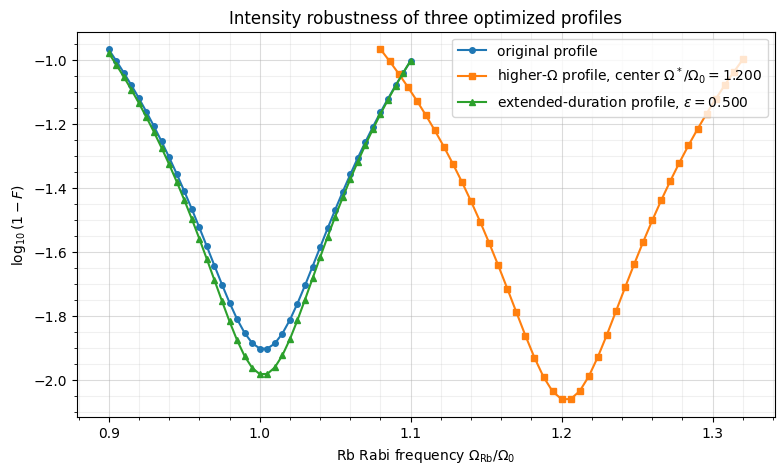

In [16]:
plt.figure(figsize=(9, 5))
plt.plot(
    original_intensity_values / omega0,
    np.log10(np.maximum(original_intensity_infidelities, 1e-16)),
    marker="o",
    markersize=4,
    label="original profile",
)
plt.plot(
    high_omega_intensity_values / omega0,
    np.log10(np.maximum(high_omega_intensity_infidelities, 1e-16)),
    marker="s",
    markersize=4,
    label=rf"higher-$\Omega$ profile, center $\Omega^*/\Omega_0={best_omega_rb / omega0:.3f}$",
)
plt.plot(
    extended_intensity_values / omega0,
    np.log10(np.maximum(extended_intensity_infidelities, 1e-16)),
    marker="^",
    markersize=4,
    label=rf"extended-duration profile, $\epsilon={selected_epsilon:.3f}$",
)
plt.xlabel(r"Rb Rabi frequency $\Omega_{\rm Rb}/\Omega_0$")
plt.ylabel(r"$\log_{10}(1-F)$")
plt.title("Intensity robustness of three optimized profiles")
plt.legend()
plt.minorticks_on()

plt.grid(True, which="major", alpha=0.45)

plt.grid(True, which="minor", alpha=0.18)
plt.show()

## Three-Profile Position-Dependent Omega-Stark Robustness

The left axis compares $\log_{10}(1-F)$ for all three phase profiles. The shared right axis shows only the two dimensionless ARC curves $\Omega_r/\Omega_0$ and $1+\Delta/\Omega_0$. The position coordinate is $r/w_0=(r/\sigma)/2$.

In [17]:
omega_stark_path = project_root / "examples" / "stabilizer_readout" / "omega_stark_values.json"
if not omega_stark_path.exists():
    raise FileNotFoundError(
        f"Missing {omega_stark_path}. Run examples/stabilizer_readout/rb_gaussian_stark_dictionary.ipynb first."
    )

raw_omega_stark_values = json.loads(omega_stark_path.read_text(encoding="utf-8"))


def parse_omega_stark_values(
    raw_values: dict[str, dict[str, float]],
) -> dict[float, dict[str, float]]:
    parsed_values: dict[float, dict[str, float]] = {}
    for key, scan_item in raw_values.items():
        if "omega_rb" not in scan_item:
            raise KeyError(f"Missing omega_rb for omega-stark entry: key={key}")
        if "rb_stark_shift" not in scan_item:
            raise KeyError(f"Missing rb_stark_shift for omega-stark entry: key={key}")
        parsed_values[float(key)] = {
            "omega_rb": float(scan_item["omega_rb"]),
            "rb_stark_shift": float(scan_item["rb_stark_shift"]),
        }
    return parsed_values


def evaluate_position_infidelity(
    omega_value: float,
    rb_stark_shift: float,
    profile_parameters: np.ndarray,
    profile_duration: float,
) -> float:
    position_problem = GrapeProblem(
        blocks=make_blocks(
            ReadoutParameters(
                omega_rb=omega_value,
                b_rb_cs=parameters.b_rb_cs,
                b_edge=parameters.b_edge,
                b_diag=parameters.b_diag,
                rb_stark_shift=rb_stark_shift,
                cs_stark_shift=0.0,
            )
        ),
        control_layout=layout,
        duration=profile_duration,
        objective=WeightedOverlapFidelity(normalizer=16.0**2),
        optimizer_settings=settings,
    )
    infidelity, _gradient = GrapeOptimizer(position_problem).evaluate(profile_parameters)
    return infidelity


omega_stark_values = parse_omega_stark_values(raw_values=raw_omega_stark_values)
omega_stark_items = sorted(omega_stark_values.items())
position_r_over_w0 = np.array(
    [position_sigma / 2.0 for position_sigma, _scan_item in omega_stark_items],
    dtype=np.float64,
)
relative_omega_profile = np.array(
    [scan_item["omega_rb"] for _key, scan_item in omega_stark_items],
    dtype=np.float64,
)
relative_delta_profile = np.array(
    [scan_item["rb_stark_shift"] for _key, scan_item in omega_stark_items],
    dtype=np.float64,
)

original_position_infidelities = np.zeros_like(position_r_over_w0)
high_omega_position_infidelities = np.zeros_like(position_r_over_w0)
extended_position_infidelities = np.zeros_like(position_r_over_w0)

for index, (_position_sigma, scan_item) in enumerate(omega_stark_items):
    relative_omega = float(scan_item["omega_rb"])
    relative_delta = float(scan_item["rb_stark_shift"])
    original_position_infidelities[index] = evaluate_position_infidelity(
        omega_value=omega0 * relative_omega,
        rb_stark_shift=omega0 * relative_delta,
        profile_parameters=result.parameters,
        profile_duration=duration,
    )
    high_omega_position_infidelities[index] = evaluate_position_infidelity(
        omega_value=best_omega_rb * relative_omega,
        rb_stark_shift=best_omega_rb * relative_delta,
        profile_parameters=best_omega_result.parameters,
        profile_duration=best_omega_duration,
    )
    extended_position_infidelities[index] = evaluate_position_infidelity(
        omega_value=omega0 * relative_omega,
        rb_stark_shift=omega0 * relative_delta,
        profile_parameters=selected_duration_result.parameters,
        profile_duration=selected_duration,
    )

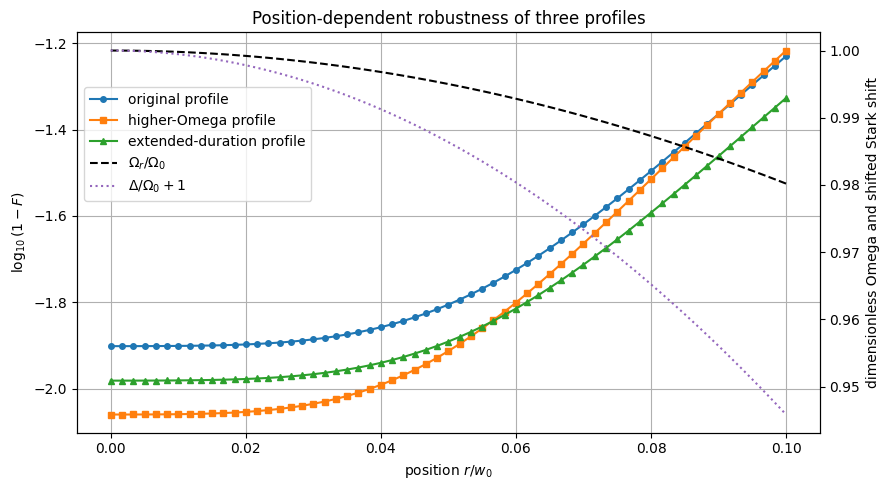

In [18]:
fig, infidelity_axis = plt.subplots(figsize=(9, 5))
parameter_axis = infidelity_axis.twinx()

infidelity_lines = []
infidelity_lines += infidelity_axis.plot(
    position_r_over_w0,
    np.log10(np.maximum(original_position_infidelities, 1e-16)),
    marker="o",
    markersize=4,
    label="original profile",
)
infidelity_lines += infidelity_axis.plot(
    position_r_over_w0,
    np.log10(np.maximum(high_omega_position_infidelities, 1e-16)),
    marker="s",
    markersize=4,
    label="higher-Omega profile",
)
infidelity_lines += infidelity_axis.plot(
    position_r_over_w0,
    np.log10(np.maximum(extended_position_infidelities, 1e-16)),
    marker="^",
    markersize=4,
    label="extended-duration profile",
)

parameter_lines = []
parameter_lines += parameter_axis.plot(
    position_r_over_w0,
    relative_omega_profile,
    color="black",
    linestyle="--",
    label=r"$\Omega_r/\Omega_0$",
)
parameter_lines += parameter_axis.plot(
    position_r_over_w0,
    1.0 + relative_delta_profile,
    color="tab:purple",
    linestyle=":",
    label=r"$\Delta/\Omega_0+1$",
)

infidelity_axis.set_xlabel(r"position $r/w_0$")
infidelity_axis.set_ylabel(r"$\log_{10}(1-F)$")
parameter_axis.set_ylabel("dimensionless Omega and shifted Stark shift")
infidelity_axis.set_title("Position-dependent robustness of three profiles")
infidelity_axis.grid(True)

all_lines = infidelity_lines + parameter_lines
infidelity_axis.legend(
    all_lines,
    [line.get_label() for line in all_lines],
    loc="upper left",
    bbox_to_anchor=(0.0, 0.88),
)
fig.tight_layout()
plt.show()

## Population Trace

The cell below traces selected states in the `m4` block. These are not all populations; they are representative basis-state populations for diagnostics.

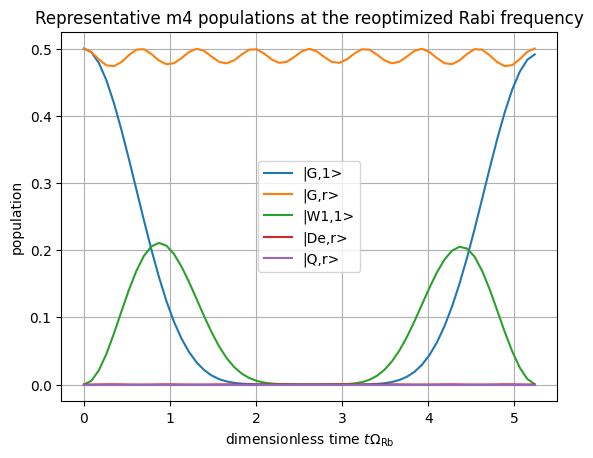

In [19]:
m4_block = next(block for block in best_omega_problem.blocks if block.name == "m4")
m4_controls = best_omega_controls

population_trace = trace_populations(
    block=m4_block,
    control_values=m4_controls,
    duration=best_omega_duration,
    samples=samples,
    states={
        "|G,1>": full_basis_state(6, 0, "1"),
        "|G,r>": full_basis_state(6, 0, "r"),
        "|W1,1>": full_basis_state(6, 1, "1"),
        "|De,r>": full_basis_state(6, 2, "r"),
        "|Q,r>": full_basis_state(6, 5, "r"),
    },
)

for label, values in population_trace.populations.items():
    plt.plot(population_trace.times, values, label=label)
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel("population")
plt.title("Representative m4 populations at the reoptimized Rabi frequency")
plt.legend()
plt.grid(True)
plt.show()

## Optional Time Scan

T*Omega_Rb=8.000, infidelity=7.749397e-09
T*Omega_Rb=7.900, infidelity=9.895794e-09
T*Omega_Rb=7.800, infidelity=7.866154e-09
T*Omega_Rb=7.700, infidelity=3.621033e-09
T*Omega_Rb=7.600, infidelity=1.384617e-10
T*Omega_Rb=7.500, infidelity=7.201930e-10
T*Omega_Rb=7.400, infidelity=6.105780e-09
T*Omega_Rb=7.300, infidelity=9.488873e-09
T*Omega_Rb=7.200, infidelity=6.802155e-09
T*Omega_Rb=7.100, infidelity=4.654083e-09
T*Omega_Rb=7.000, infidelity=5.138343e-10
T*Omega_Rb=6.900, infidelity=2.832339e-09
T*Omega_Rb=6.800, infidelity=5.289928e-09
T*Omega_Rb=6.700, infidelity=9.426250e-09
T*Omega_Rb=6.600, infidelity=9.111998e-09
T*Omega_Rb=6.500, infidelity=4.168600e-09
T*Omega_Rb=6.400, infidelity=1.478282e-10
T*Omega_Rb=6.300, infidelity=2.662961e-09
T*Omega_Rb=6.200, infidelity=1.727839e-03
T*Omega_Rb=6.100, infidelity=8.339582e-03
T*Omega_Rb=6.000, infidelity=1.976663e-02


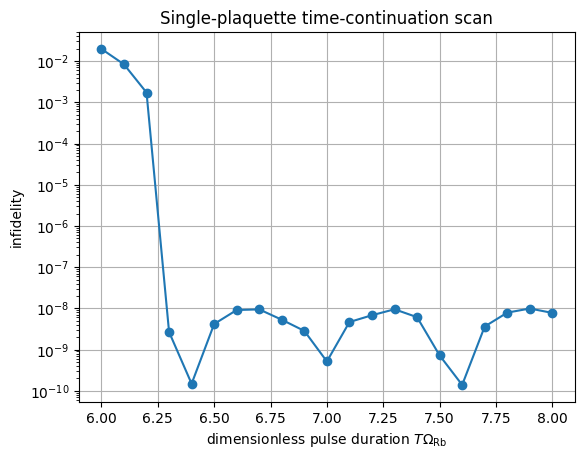

In [53]:
scan_settings = TimeScanSettings(
    start_duration=8.0,
    stop_duration=6.0,
    duration_step=0.1,
    infidelity_threshold=1e-3,
    stop_after_threshold_failure=False,
)
scan_problem = problem.with_duration(scan_settings.start_duration)
scan_points = TimeContinuationScanner(scan_problem, scan_settings).scan_with_locked_parameters(
    initial_parameters=locked_initial_parameters,
    locked_parameter_indices=locked_indices,
)

durations = np.array([point.duration for point in scan_points], dtype=np.float64)
infidelities = np.array([point.result.infidelity for point in scan_points], dtype=np.float64)
order = np.argsort(durations)

for duration_value, infidelity_value in zip(durations, infidelities, strict=True):
    print(f"T*Omega_Rb={duration_value:.3f}, infidelity={infidelity_value:.6e}")

plt.semilogy(durations[order], infidelities[order], marker="o")
plt.xlabel(r"dimensionless pulse duration $T\Omega_{\rm Rb}$")
plt.ylabel("infidelity")
plt.title("Single-plaquette time-continuation scan")
plt.grid(True)
plt.show()

## Last Scan Point Diagnostics

The cells below inspect the final point returned by the continuation scan. This is usually the shortest successful duration, or the first duration that crosses the configured infidelity threshold when `stop_after_threshold_failure=True`.

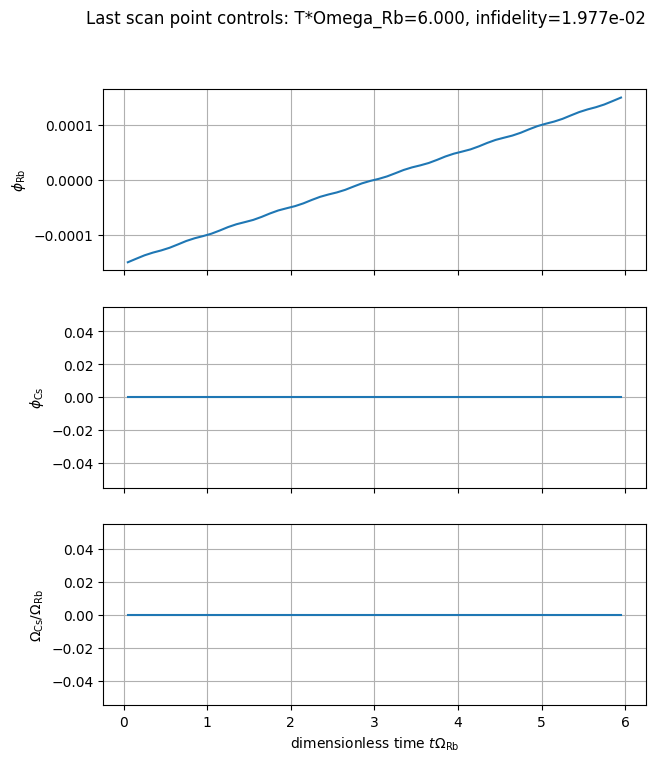

In [54]:
last_scan_point = scan_points[-1]
last_scan_controls = layout.unpack(last_scan_point.result.parameters)
last_scan_time_axis = phase_sample_axis(duration=last_scan_point.duration, samples=samples)

fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
axes[0].plot(last_scan_time_axis, unwrap_phase_profile(last_scan_controls.time_controls["phi_rb"]))
axes[0].set_ylabel(r"$\phi_{\rm Rb}$")
axes[0].grid(True)

axes[1].plot(last_scan_time_axis, unwrap_phase_profile(last_scan_controls.time_controls["phi_cs"]))
axes[1].set_ylabel(r"$\phi_{\rm Cs}$")
axes[1].grid(True)

axes[2].plot(last_scan_time_axis, last_scan_controls.time_controls["ratio_cs"])
axes[2].set_xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
axes[2].set_ylabel(r"$\Omega_{\rm Cs}/\Omega_{\rm Rb}$")
axes[2].grid(True)

fig.suptitle(
    f"Last scan point controls: "
    f"T*Omega_Rb={last_scan_point.duration:.3f}, "
    f"infidelity={last_scan_point.result.infidelity:.3e}"
)
plt.show()

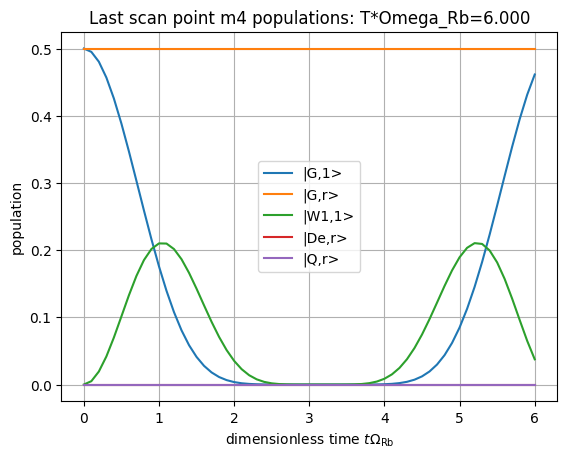

In [55]:
last_scan_m4_block = next(block for block in problem.blocks if block.name == "m4")
last_scan_population_trace = trace_populations(
    block=last_scan_m4_block,
    control_values=last_scan_controls,
    duration=last_scan_point.duration,
    samples=samples,
    states={
        "|G,1>": full_basis_state(6, 0, "1"),
        "|G,r>": full_basis_state(6, 0, "r"),
        "|W1,1>": full_basis_state(6, 1, "1"),
        "|De,r>": full_basis_state(6, 2, "r"),
        "|Q,r>": full_basis_state(6, 5, "r"),
    },
)

for label, values in last_scan_population_trace.populations.items():
    plt.plot(last_scan_population_trace.times, values, label=label)
plt.xlabel(r"dimensionless time $t\Omega_{\rm Rb}$")
plt.ylabel("population")
plt.title(
    f"Last scan point m4 populations: "
    f"T*Omega_Rb={last_scan_point.duration:.3f}"
)
plt.legend()
plt.grid(True)
plt.show()

## Interaction Fluctuations Before Robust Optimization

The two fluctuating interactions are

$$
B_1=B_{\rm Rb-Cs}=10,
\qquad
B_2=B_{\rm edge}=0.1.
$$

Both are scanned over a $\pm 10\%$ interval, so $B_1\in[9,11]$ and $B_2\in[0.09,0.11]$. The diagonal Rb-Rb interaction remains fixed at `b_diag`. Each panel uses the same color scale for $\log_{10}(1-F)$.

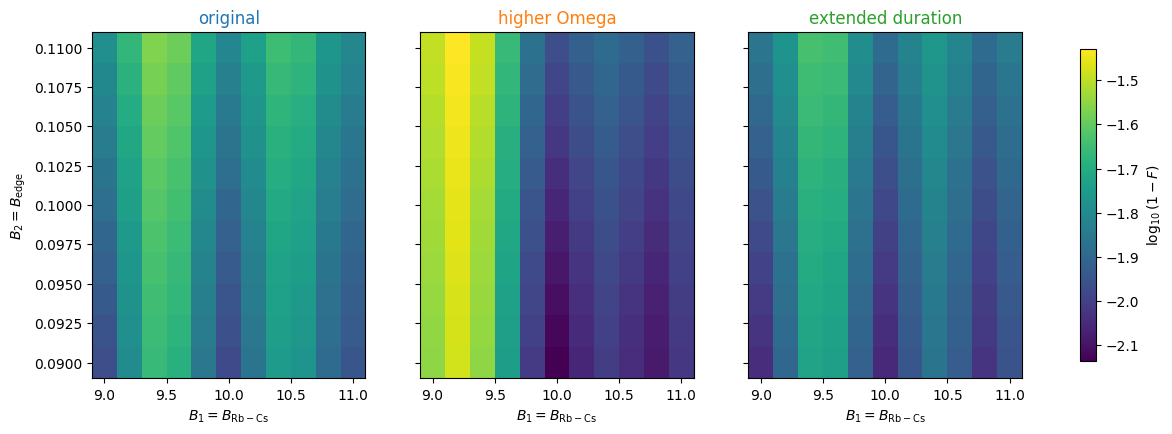

In [21]:
@dataclass(frozen=True)
class ProfileCase:
    key: str
    label: str
    color: str
    omega_rb: float
    duration: float
    baseline_result: OptimizationResult


profile_cases = (
    ProfileCase(
        key="original",
        label="original",
        color="tab:blue",
        omega_rb=omega0,
        duration=duration,
        baseline_result=result,
    ),
    ProfileCase(
        key="high_omega",
        label="higher Omega",
        color="tab:orange",
        omega_rb=best_omega_rb,
        duration=best_omega_duration,
        baseline_result=best_omega_result,
    ),
    ProfileCase(
        key="extended_duration",
        label="extended duration",
        color="tab:green",
        omega_rb=omega0,
        duration=selected_duration,
        baseline_result=selected_duration_result,
    ),
)


def make_profile_problem(
    omega_rb: float,
    b_rb_cs: float,
    b_edge: float,
    profile_duration: float,
) -> GrapeProblem:
    return GrapeProblem(
        blocks=make_blocks(
            ReadoutParameters(
                omega_rb=omega_rb,
                b_rb_cs=b_rb_cs,
                b_edge=b_edge,
                b_diag=parameters.b_diag,
                rb_stark_shift=parameters.rb_stark_shift,
                cs_stark_shift=parameters.cs_stark_shift,
            )
        ),
        control_layout=layout,
        duration=profile_duration,
        objective=WeightedOverlapFidelity(normalizer=16.0**2),
        optimizer_settings=settings,
    )


def evaluate_interaction_grid(
    profile_case: ProfileCase,
    profile_parameters: np.ndarray,
    b1_values: np.ndarray,
    b2_values: np.ndarray,
) -> np.ndarray:
    infidelities = np.zeros((b2_values.size, b1_values.size), dtype=np.float64)
    for b2_index, b2_value in enumerate(b2_values):
        for b1_index, b1_value in enumerate(b1_values):
            interaction_problem = make_profile_problem(
                omega_rb=profile_case.omega_rb,
                b_rb_cs=float(b1_value),
                b_edge=float(b2_value),
                profile_duration=profile_case.duration,
            )
            infidelity, _gradient = GrapeOptimizer(interaction_problem).evaluate(
                profile_parameters
            )
            infidelities[b2_index, b1_index] = infidelity
    return infidelities


interaction_b1_values = np.linspace(
    0.9 * parameters.b_rb_cs,
    1.1 * parameters.b_rb_cs,
    11,
    dtype=np.float64,
)
interaction_b2_values = np.linspace(
    0.9 * parameters.b_edge,
    1.1 * parameters.b_edge,
    11,
    dtype=np.float64,
)
baseline_interaction_grids = {
    profile_case.key: evaluate_interaction_grid(
        profile_case=profile_case,
        profile_parameters=profile_case.baseline_result.parameters,
        b1_values=interaction_b1_values,
        b2_values=interaction_b2_values,
    )
    for profile_case in profile_cases
}
baseline_log_interaction_grids = {
    key: np.log10(np.maximum(grid, 1e-16))
    for key, grid in baseline_interaction_grids.items()
}
baseline_color_min = min(float(np.min(grid)) for grid in baseline_log_interaction_grids.values())
baseline_color_max = max(float(np.max(grid)) for grid in baseline_log_interaction_grids.values())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
last_mesh = None
for axis, profile_case in zip(axes, profile_cases, strict=True):
    last_mesh = axis.pcolormesh(
        interaction_b1_values,
        interaction_b2_values,
        baseline_log_interaction_grids[profile_case.key],
        shading="auto",
        cmap="viridis",
        vmin=baseline_color_min,
        vmax=baseline_color_max,
    )
    axis.set_title(profile_case.label, color=profile_case.color)
    axis.set_xlabel(r"$B_1=B_{\rm Rb-Cs}$")
    axis.grid(False)
axes[0].set_ylabel(r"$B_2=B_{\rm edge}$")
if last_mesh is None:
    raise RuntimeError("No baseline interaction heatmap was generated.")
fig.colorbar(last_mesh, ax=axes, label=r"$\log_{10}(1-F)$", shrink=0.9)
# fig.suptitle("Interaction fluctuations before robust optimization")
plt.show()

## Simultaneous Robustness Optimization

For each profile, the robust cost contains three independent curvature penalties,

$$
C=1-F
-\eta_{\Omega}\frac{\partial^2F}{\partial s_{\Omega}^2}
-\eta_{B_1}\frac{\partial^2F}{\partial s_{B_1}^2}
-\eta_{B_2}\frac{\partial^2F}{\partial s_{B_2}^2},
$$

where each $s$ is a relative perturbation: $p\mapsto p(1+s)$. This normalization makes the curvature weights comparable even though the nominal parameters have very different magnitudes. Each of the three profiles has independent `eta_omega`, `eta_b1`, and `eta_b2` values, giving nine adjustable weights in total. The relative finite-difference step is configured separately.

In [49]:
@dataclass(frozen=True)
class ProfileRobustnessEtas:
    eta_omega: float
    eta_b1: float
    eta_b2: float


original_eta_omega = 4e-4
original_eta_b1 = 4e-4
original_eta_b2 = 4e-4

high_omega_eta_omega = 0e-4
high_omega_eta_b1 = 4e-4
high_omega_eta_b2 = 0.0e-4

extended_duration_eta_omega = 0e-4
extended_duration_eta_b1 = 4e-4
extended_duration_eta_b2 = 0.0e-4

profile_robustness_etas: dict[str, ProfileRobustnessEtas] = {
    "original": ProfileRobustnessEtas(
        eta_omega=original_eta_omega,
        eta_b1=original_eta_b1,
        eta_b2=original_eta_b2,
    ),
    "high_omega": ProfileRobustnessEtas(
        eta_omega=high_omega_eta_omega,
        eta_b1=high_omega_eta_b1,
        eta_b2=high_omega_eta_b2,
    ),
    "extended_duration": ProfileRobustnessEtas(
        eta_omega=extended_duration_eta_omega,
        eta_b1=extended_duration_eta_b1,
        eta_b2=extended_duration_eta_b2,
    ),
}

robustness_relative_step = 0.01

if robustness_relative_step <= 0.0:
    raise ValueError(
        f"robustness_relative_step must be positive: {robustness_relative_step}"
    )


def make_relative_penalty(
    name: str,
    plus_problem: GrapeProblem,
    minus_problem: GrapeProblem,
    eta: float,
    relative_step: float,
) -> CurvaturePenalty:
    return CurvaturePenalty(
        name=name,
        plus_problem=plus_problem,
        minus_problem=minus_problem,
        settings=CurvatureRobustnessSettings(
            eta=eta,
            finite_difference_step=relative_step,
        ),
    )


def make_robust_optimizer(
    profile_case: ProfileCase,
    robustness_etas: ProfileRobustnessEtas,
) -> MultiParameterRobustGrapeOptimizer:
    relative_plus = 1.0 + robustness_relative_step
    relative_minus = 1.0 - robustness_relative_step
    nominal_problem = make_profile_problem(
        omega_rb=profile_case.omega_rb,
        b_rb_cs=parameters.b_rb_cs,
        b_edge=parameters.b_edge,
        profile_duration=profile_case.duration,
    )
    omega_penalty = make_relative_penalty(
        name="omega_rb",
        plus_problem=make_profile_problem(
            omega_rb=profile_case.omega_rb * relative_plus,
            b_rb_cs=parameters.b_rb_cs,
            b_edge=parameters.b_edge,
            profile_duration=profile_case.duration,
        ),
        minus_problem=make_profile_problem(
            omega_rb=profile_case.omega_rb * relative_minus,
            b_rb_cs=parameters.b_rb_cs,
            b_edge=parameters.b_edge,
            profile_duration=profile_case.duration,
        ),
        eta=robustness_etas.eta_omega,
        relative_step=robustness_relative_step,
    )
    b1_penalty = make_relative_penalty(
        name="b_rb_cs",
        plus_problem=make_profile_problem(
            omega_rb=profile_case.omega_rb,
            b_rb_cs=parameters.b_rb_cs * relative_plus,
            b_edge=parameters.b_edge,
            profile_duration=profile_case.duration,
        ),
        minus_problem=make_profile_problem(
            omega_rb=profile_case.omega_rb,
            b_rb_cs=parameters.b_rb_cs * relative_minus,
            b_edge=parameters.b_edge,
            profile_duration=profile_case.duration,
        ),
        eta=robustness_etas.eta_b1,
        relative_step=robustness_relative_step,
    )
    b2_penalty = make_relative_penalty(
        name="b_edge",
        plus_problem=make_profile_problem(
            omega_rb=profile_case.omega_rb,
            b_rb_cs=parameters.b_rb_cs,
            b_edge=parameters.b_edge * relative_plus,
            profile_duration=profile_case.duration,
        ),
        minus_problem=make_profile_problem(
            omega_rb=profile_case.omega_rb,
            b_rb_cs=parameters.b_rb_cs,
            b_edge=parameters.b_edge * relative_minus,
            profile_duration=profile_case.duration,
        ),
        eta=robustness_etas.eta_b2,
        relative_step=robustness_relative_step,
    )
    return MultiParameterRobustGrapeOptimizer(
        nominal_problem=nominal_problem,
        penalties=(omega_penalty, b1_penalty, b2_penalty),
    )


robust_results: dict[str, OptimizationResult] = {}
for profile_case in profile_cases:
    if profile_case.key not in profile_robustness_etas:
        raise KeyError(
            f"Missing robustness eta configuration for profile {profile_case.key!r}."
        )
    robust_optimizer = make_robust_optimizer(
        profile_case=profile_case,
        robustness_etas=profile_robustness_etas[profile_case.key],
    )
    robust_result = robust_optimizer.optimize_with_locked_parameters(
        initial_parameters=profile_case.baseline_result.parameters,
        locked_parameter_indices=locked_indices,
    )
    robust_results[profile_case.key] = robust_result
    print(
        f"{profile_case.label}: "
        f"nominal fidelity={robust_result.fidelity:.10f}, "
        f"robust cost={robust_result.infidelity:.10e}, "
        f"success={robust_result.success}"
    )

original: nominal fidelity=0.9851491606, robust cost=2.0048507514e-02, success=True
higher Omega: nominal fidelity=0.9889478104, robust cost=7.9024008217e-03, success=True
extended duration: nominal fidelity=0.9625031024, robust cost=-6.4880794720e-04, success=True


## Phase Profiles Before and After Robust Optimization

Each panel compares one profile before and after robust optimization. The profile color is kept consistent in every following figure; dashed lines are before optimization and solid lines are after optimization. All horizontal axes use $t\Omega_0$.

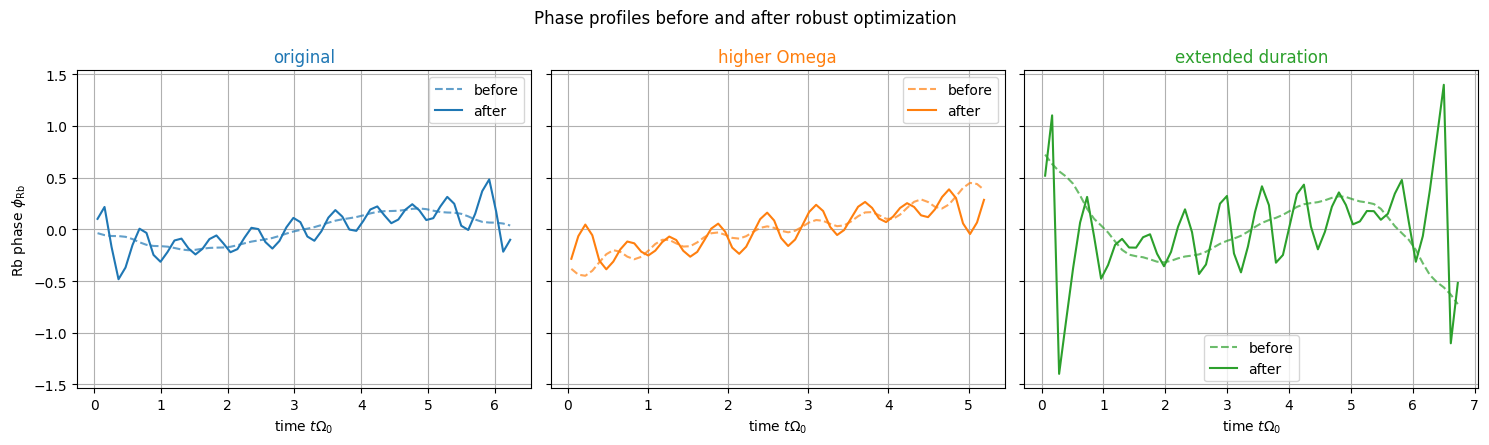

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for axis, profile_case in zip(axes, profile_cases, strict=True):
    phase_time_omega0 = phase_sample_axis(
        duration=profile_case.duration,
        samples=samples,
    ) * omega0
    baseline_controls = layout.unpack(profile_case.baseline_result.parameters)
    robust_controls = layout.unpack(robust_results[profile_case.key].parameters)
    axis.plot(
        phase_time_omega0,
        unwrap_phase_profile(baseline_controls.time_controls["phi_rb"]),
        color=profile_case.color,
        linestyle="--",
        alpha=0.7,
        label="before",
    )
    axis.plot(
        phase_time_omega0,
        unwrap_phase_profile(robust_controls.time_controls["phi_rb"]),
        color=profile_case.color,
        linestyle="-",
        label="after",
    )
    axis.set_title(profile_case.label, color=profile_case.color)
    axis.set_xlabel(r"time $t\Omega_0$")
    axis.grid(True)
    axis.legend()
axes[0].set_ylabel(r"Rb phase $\phi_{\rm Rb}$")
fig.suptitle("Phase profiles before and after robust optimization")
fig.tight_layout()
plt.show()

## Omega Robustness Before and After Optimization

Each panel scans the physical Rb Rabi frequency around that profile's own design value, while the common horizontal coordinate remains $\Omega_{\rm Rb}/\Omega_0$.

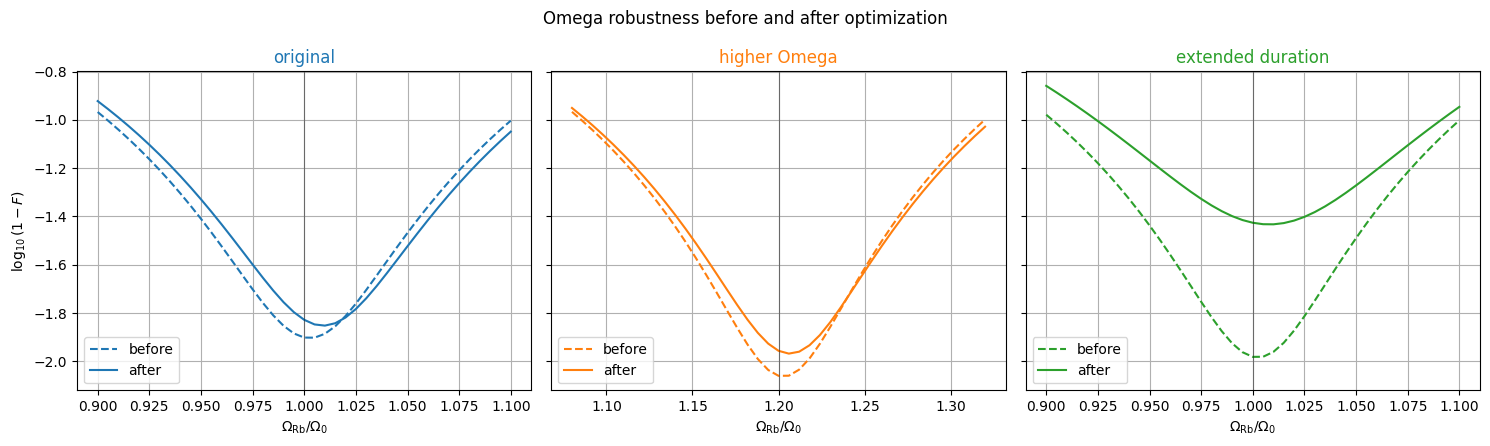

In [51]:
omega_robustness_data: dict[str, tuple[np.ndarray, np.ndarray, np.ndarray]] = {}

for profile_case in profile_cases:
    omega_scan_values = np.linspace(
        0.9 * profile_case.omega_rb,
        1.1 * profile_case.omega_rb,
        41,
        dtype=np.float64,
    )

    def make_case_omega_problem(omega_value: float) -> GrapeProblem:
        return make_profile_problem(
            omega_rb=omega_value,
            b_rb_cs=parameters.b_rb_cs,
            b_edge=parameters.b_edge,
            profile_duration=profile_case.duration,
        )

    scanned_omega_values, baseline_infidelities = scan_parameter_sensitivity(
        problem_factory=make_case_omega_problem,
        parameters=profile_case.baseline_result.parameters,
        parameter_values=omega_scan_values,
    )
    _robust_omega_values, robust_infidelities = scan_parameter_sensitivity(
        problem_factory=make_case_omega_problem,
        parameters=robust_results[profile_case.key].parameters,
        parameter_values=omega_scan_values,
    )
    omega_robustness_data[profile_case.key] = (
        scanned_omega_values,
        baseline_infidelities,
        robust_infidelities,
    )

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for axis, profile_case in zip(axes, profile_cases, strict=True):
    scanned_omega_values, baseline_infidelities, robust_infidelities = (
        omega_robustness_data[profile_case.key]
    )
    axis.plot(
        scanned_omega_values / omega0,
        np.log10(np.maximum(baseline_infidelities, 1e-16)),
        color=profile_case.color,
        linestyle="--",
        label="before",
    )
    axis.plot(
        scanned_omega_values / omega0,
        np.log10(np.maximum(robust_infidelities, 1e-16)),
        color=profile_case.color,
        linestyle="-",
        label="after",
    )
    axis.axvline(
        profile_case.omega_rb / omega0,
        color="black",
        linewidth=0.8,
        alpha=0.4,
    )
    axis.set_title(profile_case.label, color=profile_case.color)
    axis.set_xlabel(r"$\Omega_{\rm Rb}/\Omega_0$")
    axis.grid(True)
    axis.legend()
axes[0].set_ylabel(r"$\log_{10}(1-F)$")
fig.suptitle("Omega robustness before and after optimization")
fig.tight_layout()
plt.show()

## Interaction Robustness Before and After Optimization

The shared-scale $2\times3$ layout keeps profile identity in columns and optimization state in rows. This makes both comparisons direct: move horizontally to compare the three pulse designs, or vertically to see what robust optimization changed. Stark-shift robustness is intentionally omitted here.

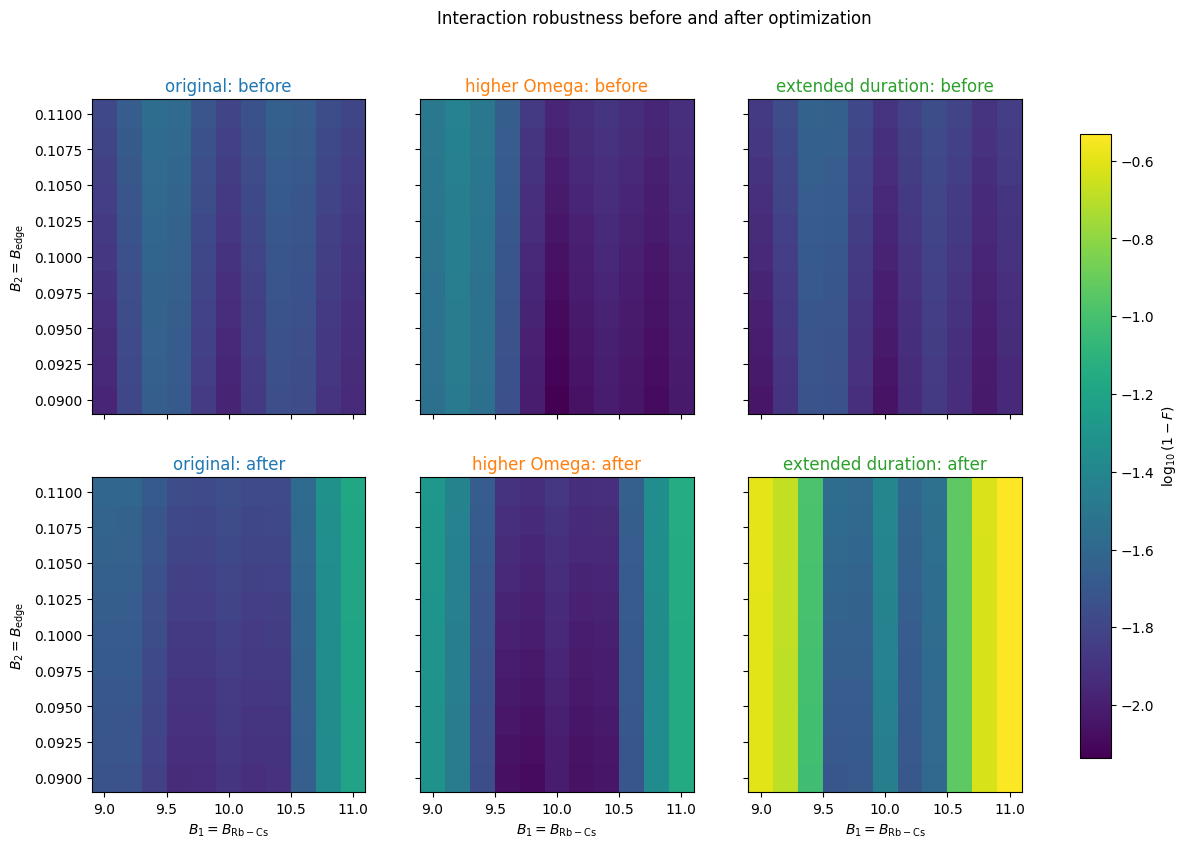

In [52]:
robust_interaction_grids = {
    profile_case.key: evaluate_interaction_grid(
        profile_case=profile_case,
        profile_parameters=robust_results[profile_case.key].parameters,
        b1_values=interaction_b1_values,
        b2_values=interaction_b2_values,
    )
    for profile_case in profile_cases
}
robust_log_interaction_grids = {
    key: np.log10(np.maximum(grid, 1e-16))
    for key, grid in robust_interaction_grids.items()
}
all_interaction_log_grids = tuple(baseline_log_interaction_grids.values()) + tuple(
    robust_log_interaction_grids.values()
)
comparison_color_min = min(float(np.min(grid)) for grid in all_interaction_log_grids)
comparison_color_max = max(float(np.max(grid)) for grid in all_interaction_log_grids)

fig, axes = plt.subplots(2, 3, figsize=(15, 9), sharex=True, sharey=True)
last_mesh = None
for column_index, profile_case in enumerate(profile_cases):
    for row_index, (row_label, grids) in enumerate(
        (
            ("before", baseline_log_interaction_grids),
            ("after", robust_log_interaction_grids),
        )
    ):
        axis = axes[row_index, column_index]
        last_mesh = axis.pcolormesh(
            interaction_b1_values,
            interaction_b2_values,
            grids[profile_case.key],
            shading="auto",
            cmap="viridis",
            vmin=comparison_color_min,
            vmax=comparison_color_max,
        )
        axis.set_title(
            f"{profile_case.label}: {row_label}",
            color=profile_case.color,
        )
        axis.grid(False)
        if row_index == 1:
            axis.set_xlabel(r"$B_1=B_{\rm Rb-Cs}$")
        if column_index == 0:
            axis.set_ylabel(r"$B_2=B_{\rm edge}$")
if last_mesh is None:
    raise RuntimeError("No interaction comparison heatmap was generated.")
fig.colorbar(last_mesh, ax=axes, label=r"$\log_{10}(1-F)$", shrink=0.9)
fig.suptitle("Interaction robustness before and after optimization")
plt.show()